In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    classification_report
)

data_path = Path("../data/processed/order_level_features.csv")

df = pd.read_csv(
    data_path,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_estimated_delivery_date"
    ]
)

df.shape

(96456, 37)

In [2]:
df["order_purchase_timestamp"].min(), df["order_purchase_timestamp"].max()

(Timestamp('2016-09-15 12:16:38'), Timestamp('2018-08-29 15:00:37'))

In [3]:
monthly_order_count = (
    df
    .assign(
        purchase_year_month=df["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("purchase_year_month")
    .size()
    .reset_index(name="order_count")
)

monthly_order_count

,purchase_year_month,order_count
0,2016-09,1
1,2016-10,265
2,2016-12,1
3,2017-01,748
4,2017-02,1641
5,2017-03,2546
6,2017-04,2303
7,2017-05,3545
8,2017-06,3135
9,2017-07,3872


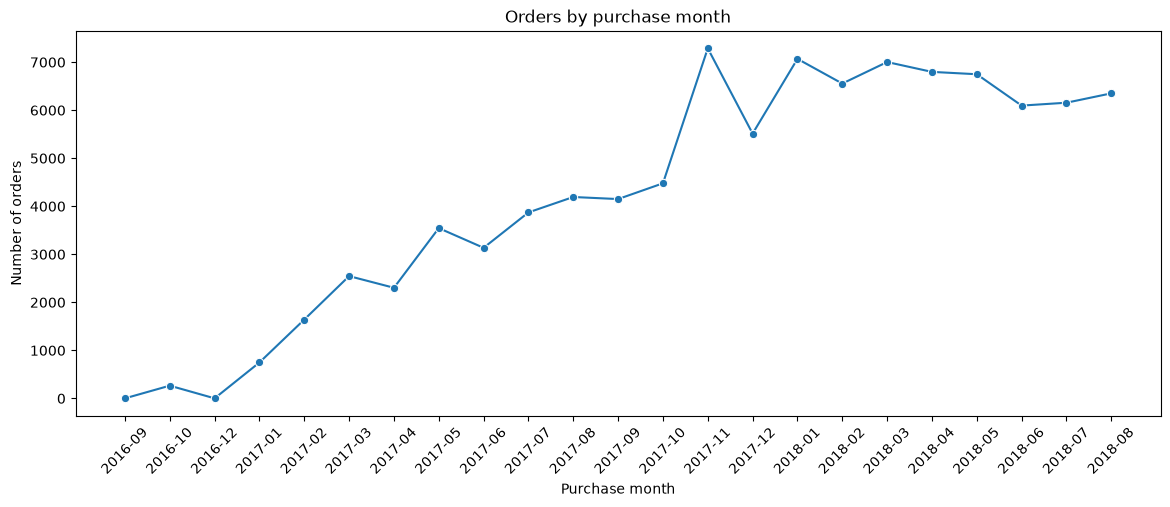

In [4]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=monthly_order_count,
    x="purchase_year_month",
    y="order_count",
    marker="o"
)

plt.title("Orders by purchase month")
plt.xlabel("Purchase month")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.show()

In [5]:
train_df = df[
    df["order_purchase_timestamp"] < "2018-01-01"
].copy()

validation_df = df[
    (df["order_purchase_timestamp"] >= "2018-01-01")
    & (df["order_purchase_timestamp"] < "2018-07-01")
].copy()

test_df = df[
    df["order_purchase_timestamp"] >= "2018-07-01"
].copy()

In [6]:
for split_name, split_df in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    print(f"\n{split_name}")
    print("Rows:", len(split_df))
    print(
        "Date range:",
        split_df["order_purchase_timestamp"].min(),
        "to",
        split_df["order_purchase_timestamp"].max()
    )
    print(
        "Late-delivery rate:",
        round(split_df["late_delivery"].mean() * 100, 2),
        "%"
    )


Train
Rows: 43679
Date range: 2016-09-15 12:16:38 to 2017-12-31 23:29:31
Late-delivery rate: 6.6 %

Validation
Rows: 40270
Date range: 2018-01-01 02:48:41 to 2018-06-30 23:59:49
Late-delivery rate: 9.95 %

Test
Rows: 12507
Date range: 2018-07-01 00:25:07 to 2018-08-29 15:00:37
Late-delivery rate: 7.48 %


In [7]:
assert (
    train_df["order_purchase_timestamp"].max()
    < validation_df["order_purchase_timestamp"].min()
)

assert (
    validation_df["order_purchase_timestamp"].max()
    < test_df["order_purchase_timestamp"].min()
)

In [8]:
numeric_features = [
    "number_of_items",
    "number_of_unique_products",
    "number_of_unique_sellers",
    "total_product_price",
    "total_freight_value",
    "average_product_weight_g",
    "average_product_length_cm",
    "average_product_height_cm",
    "average_product_width_cm",
    "number_of_product_categories",
    "total_payment_installments",
    "total_payment_value",
    "number_of_payment_records",
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "approval_delay_hours",
    "estimated_delivery_days",
    "estimated_delivery_days_invalid",
    "total_order_cost",
    "freight_ratio",
    "average_item_price",
    "average_product_volume_cm3",
    "product_dimensions_missing",
    "payment_information_missing"
]

categorical_features = [
    "customer_state",
    "primary_payment_type"
]

feature_columns = numeric_features + categorical_features

target_column = "late_delivery"

In [9]:
[column for column in feature_columns if column not in df.columns]

[]

In [10]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

In [11]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features)
    ]
)

In [12]:
def evaluate_model(model, X, y, model_name):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    return pd.DataFrame([{
        "model": model_name,
        "accuracy": round(accuracy_score(y, predictions), 4),
        "precision": round(
            precision_score(y, predictions, zero_division=0),
            4
        ),
        "recall": round(
            recall_score(y, predictions, zero_division=0),
            4
        ),
        "f1_score": round(
            f1_score(y, predictions, zero_division=0),
            4
        ),
        "roc_auc": round(roc_auc_score(y, probabilities), 4),
        "pr_auc": round(
            average_precision_score(y, probabilities),
            4
        )
    }])

In [13]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

dummy_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['number_of_items','number_of_unique_products','number_of_unique_sellers', ...,'payment_information_missing','customer_state','primary_payment_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedco

In [14]:
dummy_validation_results = evaluate_model(
    dummy_pipeline,
    X_validation,
    y_validation,
    "DummyClassifier"
)

dummy_validation_results

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,DummyClassifier,0.9005,0.0,0.0,0.0,0.5,0.0995


In [15]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['number_of_items','number_of_unique_products','number_of_unique_sellers', ...,'payment_information_missing','customer_state','primary_payment_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedco

In [16]:
logistic_validation_results = evaluate_model(
    logistic_pipeline,
    X_validation,
    y_validation,
    "Logistic Regression"
)

logistic_validation_results

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.837,0.2177,0.2458,0.2309,0.6609,0.1785


In [17]:
baseline_comparison = pd.concat(
    [
        dummy_validation_results,
        logistic_validation_results
    ],
    ignore_index=True
)

baseline_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,DummyClassifier,0.9005,0.0000,0.0000,0.0000,0.5000,0.0995
1,Logistic Regression,0.8370,0.2177,0.2458,0.2309,0.6609,0.1785


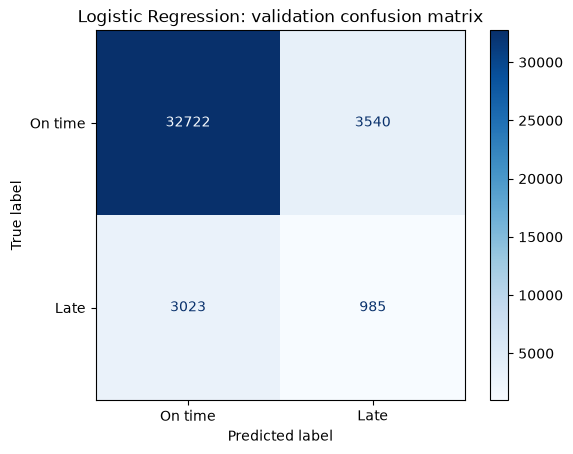

In [18]:
logistic_predictions = logistic_pipeline.predict(
    X_validation
)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_predictions,
    display_labels=["On time", "Late"],
    cmap="Blues"
)

plt.title("Logistic Regression: validation confusion matrix")
plt.show()

In [19]:
print(
    classification_report(
        y_validation,
        logistic_predictions,
        target_names=["On time", "Late"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On time       0.92      0.90      0.91     36262
        Late       0.22      0.25      0.23      4008

    accuracy                           0.84     40270
   macro avg       0.57      0.57      0.57     40270
weighted avg       0.85      0.84      0.84     40270



# Day 4 baseline results

- I used a time-based split instead of a random split to simulate predicting future orders from past data.
- Training data: orders before January 2018.
- Validation data: orders from January through June 2018.
- Test data: orders from July 2018 onward and remains untouched.
- The DummyClassifier achieved __ recall and __ PR-AUC.
- Logistic Regression achieved __ recall and __ PR-AUC.
- Logistic Regression was selected as the baseline because it identified more late orders and ranked delivery risk better than the dummy model.
- Accuracy is not sufficient because late deliveries are the minority class.